In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast

# specify GPU
device = torch.device("cuda")

Task A: Sequence Classification (Spam Ham)

In [2]:
df = pd.read_csv("spamdata_v2.csv")
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'].value_counts(normalize = True)

label
0    0.865937
1    0.134063
Name: proportion, dtype: float64

In [4]:
# split train dataset into train, validation and test sets
train_text, temp_text, train_labels, temp_labels = train_test_split(df['text'], df['label'], 
                                                                    random_state=2018, 
                                                                    test_size=0.3, 
                                                                    stratify=df['label'])


val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, 
                                                                random_state=2018, 
                                                                test_size=0.5, 
                                                                stratify=temp_labels)

From the 5572 row of df: the 70% (=3900) are train and 30%(=1672) are temp(or initial test). From 1672 row of temp: 50% (=836) is val and remain 50%(=836) is test.

In [5]:
print(df.shape,train_text.shape,temp_text.shape,train_labels.shape,temp_labels.shape)
print(val_text.shape, test_text.shape, val_labels.shape, test_labels.shape)


(5572, 2) (3900,) (1672,) (3900,) (1672,)
(836,) (836,) (836,) (836,)


In [6]:
# import BERT-base pretrained model
bert = AutoModel.from_pretrained('bert-base-uncased')

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')


2025-07-29 13:26:27.346366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753795587.500661    3165 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753795587.546018    3165 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753795587.902049    3165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753795587.902111    3165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753795587.902115    3165 computation_placer.cc:177] computation placer alr

In [7]:
# get length of all the messages in the train set
seq_len = [len(i.split()) for i in train_text]

print(train_text.head())

print(train_text[1188].split())

print(len(train_text[1188].split()))

seq_len[0]

1188    All will come alive.better correct any good lo...
5403             So gd got free ice cream... I oso wan...
2924                     Are you coming to day for class.
880     Reminder: You have not downloaded the content ...
719     Macha dont feel upset.i can assume your mindse...
Name: text, dtype: object
['All', 'will', 'come', 'alive.better', 'correct', 'any', 'good', 'looking', 'figure', 'there', 'itself..']
11


11

<Axes: >

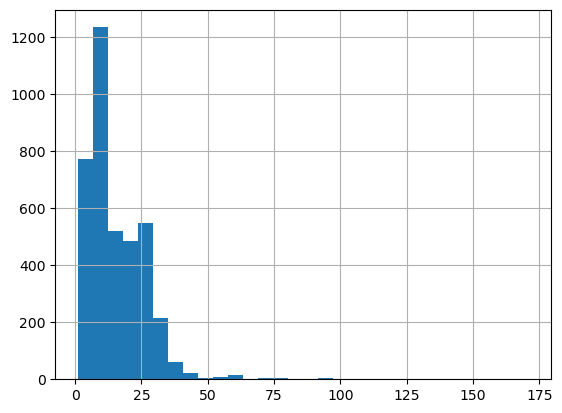

In [8]:
pd.Series(seq_len).hist(bins = 30)

In [11]:
# tokenize and encode sequences in the training set
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length=25,
    padding='max_length',
    truncation=True
)

# tokenize and encode sequences in the validation set
tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    max_length=25,
    padding='max_length',
    truncation=True
)

# tokenize and encode sequences in the test set
tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length=25,
    padding='max_length',
    truncation=True
)
print(tokens_train[0:1])
print(tokens_val[0:1])
print(tokens_test[0:1])

[Encoding(num_tokens=25, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])]
[Encoding(num_tokens=25, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])]
[Encoding(num_tokens=25, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])]


In [12]:
## convert lists to tensors

train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

In [13]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#define a batch size
batch_size = 32

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

In [14]:
# freeze all the parameters
for param in bert.parameters():
    param.requires_grad = False


In [16]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):
        super(BERT_Arch, self).__init__()
        
        self.bert = bert 
        
        # dropout layer
        self.dropout = nn.Dropout(0.1)
      
        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(768,512)
      
        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(512,2)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):
        
        #pass the inputs to the model  
        _, cls_hs = self.bert(sent_id, attention_mask=mask, return_dict=False)
      
        x = self.fc1(cls_hs)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)
      
        # apply softmax activation
        x = self.softmax(x)

        return x
# pass the pre-trained BERT to our define architecture
model = BERT_Arch(bert)

# push the model to GPU
model = model.to(device)


In [9]:
from torch.optim import AdamW

In [23]:
# optimizer from torch
from torch.optim import AdamW

# define the optimizer
optimizer = AdamW(model.parameters(), lr=1e-5)
from sklearn.utils.class_weight import compute_class_weight

#compute the class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)

print("Class Weights:",class_weights)
# converting list of class weights to a tensor
weights= torch.tensor(class_weights,dtype=torch.float)

# push to GPU
weights = weights.to(device)

# define the loss function
cross_entropy  = nn.NLLLoss(weight=weights) 

# number of training epochs
epochs = 50


Class Weights: [0.57743559 3.72848948]


In [29]:
print(bert)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [24]:
# function to train the model
def train():
    
    model.train()
    total_loss, total_accuracy = 0, 0
  
    # empty list to save model predictions
    total_preds=[]
  
    # iterate over batches
    for step,batch in enumerate(train_dataloader):
        
        # progress update after every 50 batches.
        if step % 50 == 0 and not step == 0:
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))
        
        # push the batch to gpu
        batch = [r.to(device) for r in batch]
 
        sent_id, mask, labels = batch
        
        # clear previously calculated gradients 
        model.zero_grad()        

        # get model predictions for the current batch
        preds = model(sent_id, mask)

        # compute the loss between actual and predicted values
        loss = cross_entropy(preds, labels)

        # add on to the total loss
        total_loss = total_loss + loss.item()

        # backward pass to calculate the gradients
        loss.backward()

        # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update parameters
        optimizer.step()

        # model predictions are stored on GPU. So, push it to CPU
        preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    # compute the training loss of the epoch
    avg_loss = total_loss / len(train_dataloader)
  
      # predictions are in the form of (no. of batches, size of batch, no. of classes).
      # reshape the predictions in form of (number of samples, no. of classes)
    total_preds  = np.concatenate(total_preds, axis=0)

    #returns the loss and predictions
    return avg_loss, total_preds
# function for evaluating the model
def evaluate():
    
    print("\nEvaluating...")
  
    # deactivate dropout layers
    model.eval()

    total_loss, total_accuracy = 0, 0
    
    # empty list to save the model predictions
    total_preds = []

    # iterate over batches
    for step,batch in enumerate(val_dataloader):
        
        # Progress update every 50 batches.
        if step % 50 == 0 and not step == 0:
            
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)
            
            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader)))

        # push the batch to gpu
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # deactivate autograd
        with torch.no_grad():
            
            # model predictions
            preds = model(sent_id, mask)

            # compute the validation loss between actual and predicted values
            loss = cross_entropy(preds,labels)

            total_loss = total_loss + loss.item()

            preds = preds.detach().cpu().numpy()

            total_preds.append(preds)

    # compute the validation loss of the epoch
    avg_loss = total_loss / len(val_dataloader) 

    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds  = np.concatenate(total_preds, axis=0)

    return avg_loss, total_preds
# set initial loss to infinite
best_valid_loss = float('inf')

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]

#for each epoch
for epoch in range(epochs):
     
    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))
    
    #train model
    train_loss, _ = train()
    
    #evaluate model
    valid_loss, _ = evaluate()
    
    #save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'saved_weights.pt')
    
    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')


 Epoch 1 / 50


/home/kelvin/miniconda3/envs/linux-deep-gpu/lib/python3.12/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.470
Validation Loss: 0.438

 Epoch 2 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.455
Validation Loss: 0.424

 Epoch 3 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.452
Validation Loss: 0.414

 Epoch 4 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.431
Validation Loss: 0.399

 Epoch 5 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.422
Validation Loss: 0.388

 Epoch 6 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.411
Validation Loss: 0.378

 Epoch 7 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.402
Validation Loss: 0.370

 Epoch 8 / 50
  Batch    50  of    122.
  Batch   100  of    122.

Evaluating...

Training Loss: 0.395
Validation Loss: 0.358

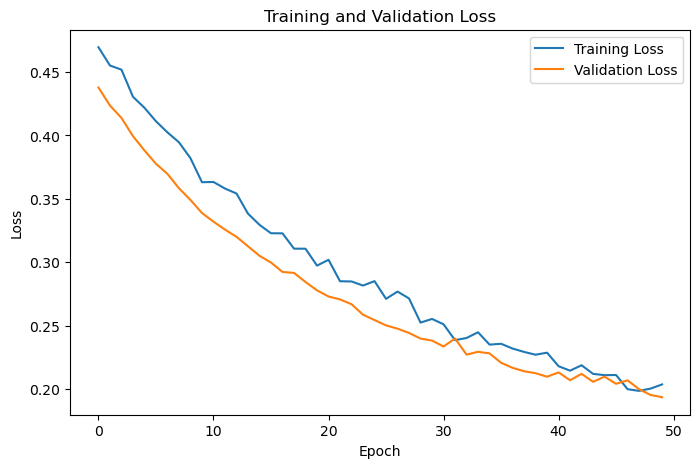

              precision    recall  f1-score   support

         ham       0.98      0.96      0.97       724
        spam       0.78      0.89      0.83       112

    accuracy                           0.95       836
   macro avg       0.88      0.93      0.90       836
weighted avg       0.96      0.95      0.95       836



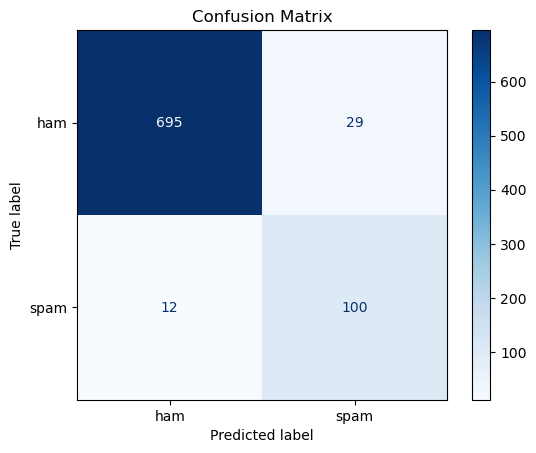

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Load the best model weights
model.load_state_dict(torch.load('saved_weights.pt'))
model.eval()

# Get predictions on validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_dataloader:
        batch = [t.to(device) for t in batch]
        sent_id, mask, labels = batch
        outputs = model(sent_id, mask)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=['ham', 'spam']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Task B: Token Classification (Named Entity Recognition)

In [27]:
%pip install seqeval

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16217 sha256=8896f35881898f9509465234adf0fd35432236798d2350bda42393a1cbfa6bbe
  Stored in directory: /home/kelvin/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import BertForTokenClassification, BertTokenizerFast
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from seqeval.metrics import classification_report, f1_score
import seaborn as sns

# Load dataset
dataset = load_dataset("conll2003")
label_list = dataset["train"].features["ner_tags"].feature.names


Epoch 1:   0%|          | 0/3511 [00:00<?, ?it/s]

RuntimeError: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.cuda.FloatTensor instead (while checking arguments for embedding)

In [31]:

# Initialize model and tokenizer
model_name = "dbmdz/bert-large-cased-finetuned-conll03-english"  # Pre-finetuned for NER
tokenizer = BertTokenizerFast.from_pretrained(model_name)
model = BertForTokenClassification.from_pretrained(model_name)


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [54]:
from transformers import pipeline

# Create a pipeline for NER (easiest way)
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Input sentence
text = "Elon Musk founded SpaceX and was born in South Africa."

# Run NER
entities = ner_pipeline(text)

# Print entities
for entity in entities:
    print(f"{entity['word']} -> {entity['entity_group']} (score: {entity['score']:.4f})")

Device set to use cuda:0
/home/kelvin/miniconda3/envs/linux-deep-gpu/lib/python3.12/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Elon Musk -> PER (score: 0.9980)
SpaceX -> ORG (score: 0.9992)
South Africa -> LOC (score: 0.9993)


In [56]:
from transformers import BertTokenizerFast, BertForTokenClassification
import torch

# Input text
text = "Barack Obama was the 44th President of the United States."

# Tokenize input
inputs = tokenizer(text, return_tensors="pt", is_split_into_words=False)
inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move inputs to the same device as model
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predictions = torch.argmax(logits, dim=2)

# Get label mappings
labels = model.config.id2label

# Decode tokens and predictions
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
predicted_labels = [labels[p.item()] for p in predictions[0]]

for token, label in zip(tokens, predicted_labels):
    print(f"{token}: {label}")


[CLS]: O
Barack: I-PER
Obama: I-PER
was: O
the: O
44: O
##th: O
President: O
of: O
the: O
United: I-LOC
States: I-LOC
.: O
[SEP]: O


/home/kelvin/miniconda3/envs/linux-deep-gpu/lib/python3.12/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
# Visualization function
def visualize_ner(text):
    tokens = tokenizer.tokenize(text)
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    predictions = torch.argmax(outputs.logits, dim=-1)[0].cpu().numpy().tolist()
    predicted_tags = [label_list[p] for p in predictions[1:-1]]  # Skip [CLS] and [SEP]
    
    # Create visualization
    from IPython.display import display, HTML
    
    html = "<div style='font-family: monospace; line-height: 1.5;'>"
    for token, tag in zip(tokens, predicted_tags):
        color = "black"
        if tag != "O":
            color = "red" if "LOC" in tag else "blue" if "PER" in tag else "green" if "ORG" in tag else "purple"
            html += f"<strong style='color: {color}'>{token} ({tag})</strong> "
        else:
            html += f"{token} "
    html += "</div>"
    
    display(HTML(html))

# Example usage
sample_text = "Apple is looking at buying U.K. startup for $1 billion and John Smith is the CEO."

visualize_ner(sample_text)

In [58]:
ner_sample_texts = {"Elon Musk founded SpaceX and was born in South Africa.",
                    "Barack Obama was the 44th President of the United States.",
                    "Apple is looking at buying U.K. startup for $1 billion.",
                    "John Smith is the CEO of a major corporation."}
for text in ner_sample_texts:
    visualize_ner(text)

/home/kelvin/miniconda3/envs/linux-deep-gpu/lib/python3.12/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [59]:
# Visualization of NER tags
def visualize_ner(text):
    tokens = tokenizer.tokenize(tokenizer.decode(tokenizer.encode(text)))
    inputs = tokenizer.encode(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(inputs)
    
    predictions = torch.argmax(outputs.logits, dim=-1)[0].cpu().numpy().tolist()
    predicted_tags = [label_list[p] for p in predictions[1:-1]]  # Skip [CLS] and [SEP]
    
    # Create color mapping
    color_map = {
        'O': 'white',
        'B-PER': 'lightgreen',
        'I-PER': 'green',
        'B-ORG': 'lightblue',
        'I-ORG': 'blue',
        'B-LOC': 'lightcoral',
        'I-LOC': 'red',
        'B-MISC': 'lightyellow',
        'I-MISC': 'yellow'
    }
    
    # Create HTML visualization
    html = "<div style='border:1px solid #ccc; padding:10px;'>"
    for token, tag in zip(tokens[1:-1], predicted_tags):  # Skip [CLS] and [SEP]
        color = color_map.get(tag, 'white')
        html += f"<span style='background-color:{color}; margin:2px; padding:2px;'>{token} ({tag})</span> "
    html += "</div>"
    
    from IPython.display import HTML
    return HTML(html)

# Example usage
sample_text = "Apple is looking at buying U.K. startup for $1 billion and John Smith is the CEO."
visualize_ner(sample_text)

Task C: Question Answering

In [1]:
from transformers import BertTokenizerFast, BertForQuestionAnswering
from datasets import load_dataset

# Load pre-trained tokenizer and model
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
model = BertForQuestionAnswering.from_pretrained('bert-base-uncased')

# Load SQuAD v1.1
dataset = load_dataset("squad")


2025-07-29 16:52:34.940678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753807955.069137   38605 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753807955.118770   38605 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753807955.266254   38605 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753807955.266507   38605 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753807955.266513   38605 computation_placer.cc:177] computation placer alr

In [2]:
def preprocess(examples):
    # Tokenize
    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length"
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")
    
    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        # Find the example this feature comes from
        sample_idx = sample_mapping[i]
        answers = examples["answers"][sample_idx]
        if len(answers["answer_start"]) == 0:
            # No answer
            start_positions.append(cls_index)
            end_positions.append(cls_index)
            continue

        answer_start = answers["answer_start"][0]
        answer_text = answers["text"][0]
        answer_end = answer_start + len(answer_text)

        sequence_ids = tokenized.sequence_ids(i)
        # Find the start and end of the context in the input_ids
        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        # Start token index
        token_start_index = context_start
        token_end_index = context_end

        # Move the token_start_index to the first token that is at or after the answer start
        while token_start_index < len(offsets) and offsets[token_start_index][0] <= answer_start:
            token_start_index += 1
        # Move the token_end_index to the last token that is at or before the answer end
        while token_end_index >= 0 and offsets[token_end_index][1] >= answer_end:
            token_end_index -= 1

        start_positions.append(token_start_index - 1 if token_start_index > context_start else cls_index)
        end_positions.append(token_end_index + 1 if token_end_index < context_end else cls_index)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"] = end_positions
    return tokenized

train_dataset = dataset["train"].map(preprocess, batched=True, remove_columns=dataset["train"].column_names)
val_dataset = dataset["validation"].map(preprocess, batched=True, remove_columns=dataset["validation"].column_names)


In [3]:
print(train_dataset[0].keys())
print(train_dataset[0]["input_ids"])

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'])
[101, 2000, 3183, 2106, 1996, 6261, 2984, 9382, 3711, 1999, 8517, 1999, 10223, 26371, 2605, 1029, 102, 6549, 2135, 1010, 1996, 2082, 2038, 1037, 3234, 2839, 1012, 10234, 1996, 2364, 2311, 1005, 1055, 2751, 8514, 2003, 1037, 3585, 6231, 1997, 1996, 6261, 2984, 1012, 3202, 1999, 2392, 1997, 1996, 2364, 2311, 1998, 5307, 2009, 1010, 2003, 1037, 6967, 6231, 1997, 4828, 2007, 2608, 2039, 14995, 6924, 2007, 1996, 5722, 1000, 2310, 3490, 2618, 4748, 2033, 18168, 5267, 1000, 1012, 2279, 2000, 1996, 2364, 2311, 2003, 1996, 13546, 1997, 1996, 6730, 2540, 1012, 3202, 2369, 1996, 13546, 2003, 1996, 24665, 23052, 1010, 1037, 14042, 2173, 1997, 7083, 1998, 9185, 1012, 2009, 2003, 1037, 15059, 1997, 1996, 24665, 23052, 2012, 10223, 26371, 1010, 2605, 2073, 1996, 6261, 2984, 22353, 2135, 2596, 2000, 3002, 16595, 9648, 4674, 2061, 12083, 9711, 2271, 1999, 8517, 1012, 2012, 1996, 2203, 1997, 1996, 2364, 3298

In [4]:
from torch.utils.data import DataLoader
from transformers import default_data_collator
train_dataset = train_dataset.select(range(500))
val_dataset = val_dataset.select(range(500))
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=default_data_collator)
val_dataloader = DataLoader(val_dataset, batch_size=16, collate_fn=default_data_collator)


In [5]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

optimizer = AdamW(model.parameters(), lr=3e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_vals = []
scaler = torch.cuda.amp.GradScaler()

for epoch in range(20):
    model.train()
    total_loss = 0
    for batch in tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}"):
        batch = {k: v.to(device) for k, v in batch.items()}


        with torch.cuda.amp.autocast():
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataloader)
    loss_vals.append(avg_loss)
    print(f"\nEpoch {epoch+1} Loss: {avg_loss:.4f}")


    avg_loss = total_loss / len(train_dataloader)
    loss_vals.append(avg_loss)
    print(f"\nEpoch {epoch+1} Loss: {avg_loss:.4f}")


/tmp/ipykernel_38605/2165379415.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Training Epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_38605/2165379415.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/home/kelvin/miniconda3/envs/linux-deep-gpu/lib/python3.12/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Training Epoch 1: 100%|██████████| 32/32 [00:34<00:00,  1.08s/it]



Epoch 1 Loss: 4.8769

Epoch 1 Loss: 4.8769


Training Epoch 2: 100%|██████████| 32/32 [00:34<00:00,  1.07s/it]



Epoch 2 Loss: 3.2040

Epoch 2 Loss: 3.2040


Training Epoch 3: 100%|██████████| 32/32 [00:34<00:00,  1.07s/it]


...


Epoch 18 Loss: 0.0852

Epoch 18 Loss: 0.0852


Training Epoch 19: 100%|██████████| 32/32 [00:34<00:00,  1.07s/it]



Epoch 19 Loss: 0.0969

Epoch 19 Loss: 0.0969


Training Epoch 20: 100%|██████████| 32/32 [00:34<00:00,  1.07s/it]


Epoch 20 Loss: 0.0466

Epoch 20 Loss: 0.0466


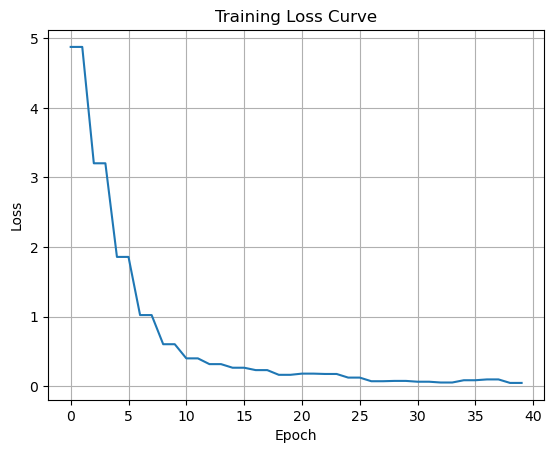

In [6]:
plt.plot(loss_vals)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [10]:
# %pip install evaluate

from evaluate import load as load_metric

metric = load_metric("squad")

model.eval()
predictions = []
references = []

for batch in tqdm(val_dataloader, desc="Evaluating"):
    with torch.no_grad():
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

    start_logits = outputs.start_logits.cpu()
    end_logits = outputs.end_logits.cpu()

    for i in range(len(batch["input_ids"])):
        input_ids = batch["input_ids"][i].cpu().tolist()
        start_idx = torch.argmax(start_logits[i])
        end_idx = torch.argmax(end_logits[i]) + 1
        answer = tokenizer.decode(input_ids[start_idx:end_idx])

        predictions.append({"id": str(i), "prediction_text": answer})
        references.append({"id": str(i), "answers": {"text": ["dummy"], "answer_start": [0]}})

results = metric.compute(predictions=predictions, references=references)
print(results)


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  2.95it/s]

{'exact_match': 0.0, 'f1': 0.0}


In [21]:
from sklearn.metrics import classification_report
import ipywidgets as widgets
from IPython.display import display, HTML
question = []
# Get the first 3 questions from the validation dataset
for i in range(3):
    input_ids = batch["input_ids"][i]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    start_idx = torch.argmax(start_logits[i])
    end_idx = torch.argmax(end_logits[i])
    answer_tokens = tokens[start_idx:end_idx+1]
    answer = tokenizer.convert_tokens_to_string(answer_tokens)
    print(f"\nPrediction {i+1}: {answer}")
    # Visualize answer span in tokens
    # Fetch the question from the original validation dataset
    question_text = " ".join(tokens)
    question.append(question_text)
    print("Question:", question_text)
    print("Tokens:", tokens)
    print("Questions:", question)

    print("Answer tokens:", answer_tokens)

    # Optionally, highlight the answer in the original context if available
    # Try to reconstruct the answer span in the context using offsets if possible
    if "offset_mapping" in batch:
        offsets = batch["offset_mapping"][i]
        # Some datasets may not provide offset_mapping, so check type
        if isinstance(offsets, torch.Tensor):
            offsets = offsets.cpu().tolist()
        start_char = offsets[start_idx][0]
        end_char = offsets[end_idx][1]
        # You need the original context for this sample; if not available, skip
        print("Answer in context:", context[start_char:end_char])

# Model report on validation set

# Collect predictions and true answers for the batch
pred_texts = []
true_texts = []
for i in range(len(batch["input_ids"])):
    tokens = tokenizer.convert_ids_to_tokens(batch["input_ids"][i])
    s_idx = torch.argmax(start_logits[i])
    e_idx = torch.argmax(end_logits[i])
    ans_tokens = tokens[s_idx:e_idx+1]
    pred_text = tokenizer.convert_tokens_to_string(ans_tokens)
    pred_texts.append(pred_text)
    # True answer text (if available in batch)
    # If using SQuAD-style, you may need to fetch from references
    if "start_positions" in batch and "end_positions" in batch:
        true_tokens = tokens[batch["start_positions"][i]:batch["end_positions"][i]+1]
        true_text = tokenizer.convert_tokens_to_string(true_tokens)
        true_texts.append(true_text)

print("\nSample Model Report:")
for idx in range(min(3, len(pred_texts))):
    print(f"Prediction: {pred_texts[idx]}")
    if idx < len(true_texts):
        print(f"Ground Truth: {true_texts[idx]}")

def highlight_answer(context, answer):
    if not answer or answer.strip() == "":
        return context
    idx = context.lower().find(answer.lower())
    if idx == -1:
        return context
    end_idx = idx + len(answer)
    return (
        context[:idx]
        + f"<span style='background-color: #ffe066; font-weight:bold'>{context[idx:end_idx]}</span>"
        + context[end_idx:]
    )

def qa_visual_report(pred_texts, true_texts, context, question, n=3):
    items = []
    for i in range(min(n, len(pred_texts))):
        pred = pred_texts[i]
        gt = true_texts[i] if i < len(true_texts) else ""
        html = f"""
        <div style='border:1px solid #ccc; margin:8px; padding:8px;'>
            <b>Question:</b> {question[i]}<br>
            <b>Prediction:</b> <span style='color:blue'>{pred}</span><br>
            <b>Ground Truth:</b> <span style='color:green'>{gt}</span><br>
            
        </div>
        """
        items.append(widgets.HTML(value=html))
    accordion = widgets.Accordion(children=items)
    for i in range(len(items)):
        accordion.set_title(i, f"Sample {i+1}")
    display(accordion)

# Show interactive QA visual report for first 3 samples
qa_visual_report(pred_texts, true_texts, context, question, n=3)


Prediction 1: week
Question: [CLS] how long will the event at santa clara convention center last ? [SEP] in addition , there are $ 2 million worth of other an ##ci ##llary events , including a week - long event at the santa clara convention center , a beer , wine and food festival at bell ##omy field at santa clara university , and a pep rally . a professional fundraiser will aid in finding business sponsors and individual donors , but still may need the city council to help fund the event . additional funding will be provided by the city council , which has announced plans to set aside seed funding for the event . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD

Accordion(children=(HTML(value="\n        <div style='border:1px solid #ccc; margin:8px; padding:8px;'>\n     …

In [14]:
from IPython.display import display, HTML
# QA Visualization with proper offset handling
def visualize_qa(question, context):
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=384,
        return_offsets_mapping=True
    )
    offset_mapping = inputs.pop("offset_mapping")  # Remove offset_mapping before sending to model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get the answer span
    answer_start = torch.argmax(outputs.start_logits)
    answer_end = torch.argmax(outputs.end_logits) + 1
    
    # Convert token positions to character positions
    offsets = offset_mapping[0]
    start_char = offsets[answer_start][0].item()
    end_char = offsets[answer_end-1][1].item()
    answer = context[start_char:end_char]
    
    # Highlight answer in context
    highlighted_context = (
        context[:start_char] +
        f"<span style='background-color:grey'>{context[start_char:end_char]}</span>" +
        context[end_char:]
    )
    
    display(HTML(f"""
    <div style='border:1px solid #ccc; padding:10px; margin-bottom:10px;'>
        <h3>Question:</h3>
        <p>{question}</p>
        <h3>Context:</h3>
        <p>{highlighted_context}</p>
        <h3>Answer:</h3>
        <p style='color:green; font-weight:bold;'>{answer}</p>
    </div>
    """))

# Example usage
context = """
The Apollo program, also known as Project Apollo, was the third United States human spaceflight program carried out by the National Aeronautics and Space Administration (NASA), which succeeded in landing the first humans on the Moon from 1969 to 1972.
"""
question = "Which NASA program landed the first humans on the Moon?"
visualize_qa(question, context)